# Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to explore the vehicle motion sensor data through statistical visualizations. Exploratory Data Analysis helps identify data distributions, class-wise differences, relationships between features, and potential patterns that can improve machine learning model performance.

---

## Dataset

Raw Sensor Dataset (`sensor_raw.csv`)

In [21]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

plt.style.use("default")
sns.set_theme(style="whitegrid")

raw_df = pd.read_csv("../data/sensor_raw.csv")

## Distribution of Driving Behavior Classes

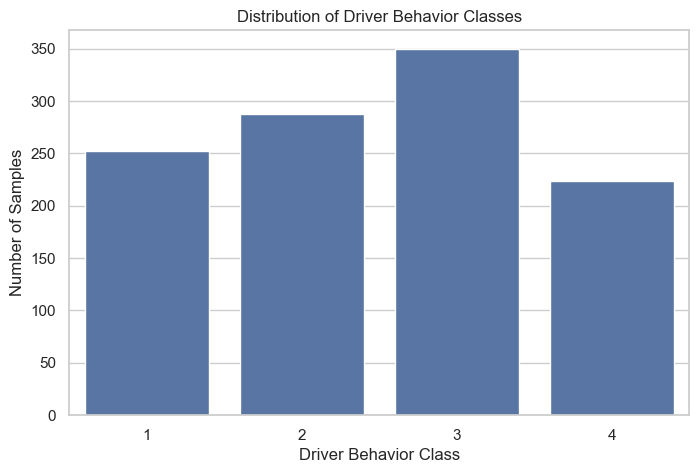

In [22]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=raw_df,
    x="Target(Class)"
)

plt.title("Distribution of Driver Behavior Classes")
plt.xlabel("Driver Behavior Class")
plt.ylabel("Number of Samples")
plt.savefig("C:/Users/htupk/OneDrive/Desktop/DriveIntel/reports/figures/Distribution_of_driving_behaviour_class.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The four driving behavior classes are reasonably balanced, although Class 3 contains the highest number of observations while Class 4 has the fewest. The imbalance is small and should not significantly affect model training.

## Feature Distributions

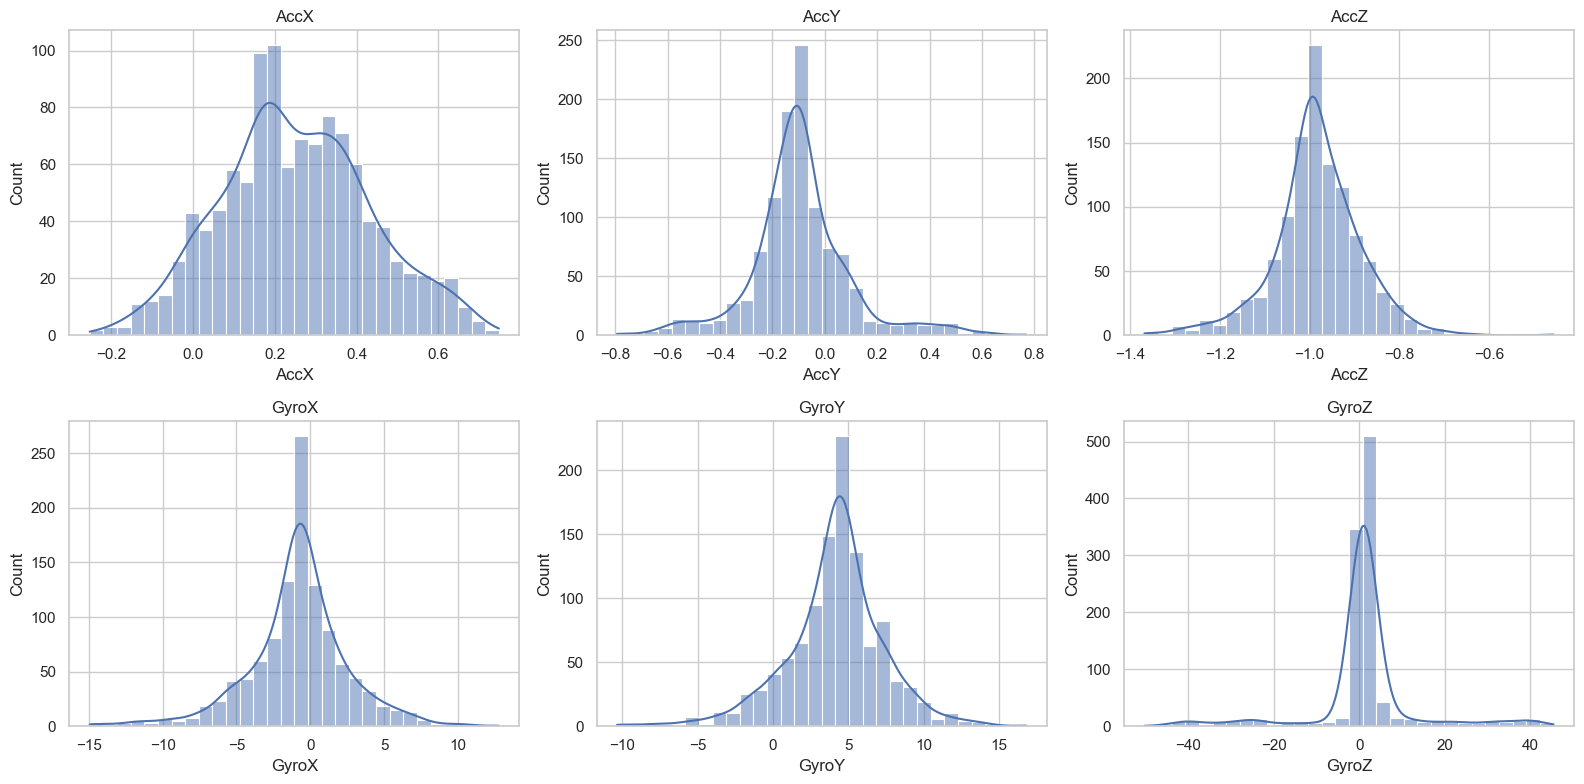

In [23]:
features = ["AccX","AccY","AccZ","GyroX","GyroY","GyroZ"]

fig, axes = plt.subplots(2,3, figsize=(16,8))

for feature, ax in zip(features, axes.flatten()):

    sns.histplot(
        raw_df[feature],
        bins=30,
        kde=True,
        ax=ax
    )

    ax.set_title(feature)

plt.tight_layout()
plt.savefig("C:/Users/htupk/OneDrive/Desktop/DriveIntel/reports/figures/Feature_Distributions.png", dpi=300, bbox_inches="tight")
plt.show()

### Observation

The sensor features exhibit different distributions, with several showing skewness and varying ranges. Some variables contain extreme values, suggesting the presence of sudden vehicle movements or abrupt driving events.

## Boxplots by Driving Class

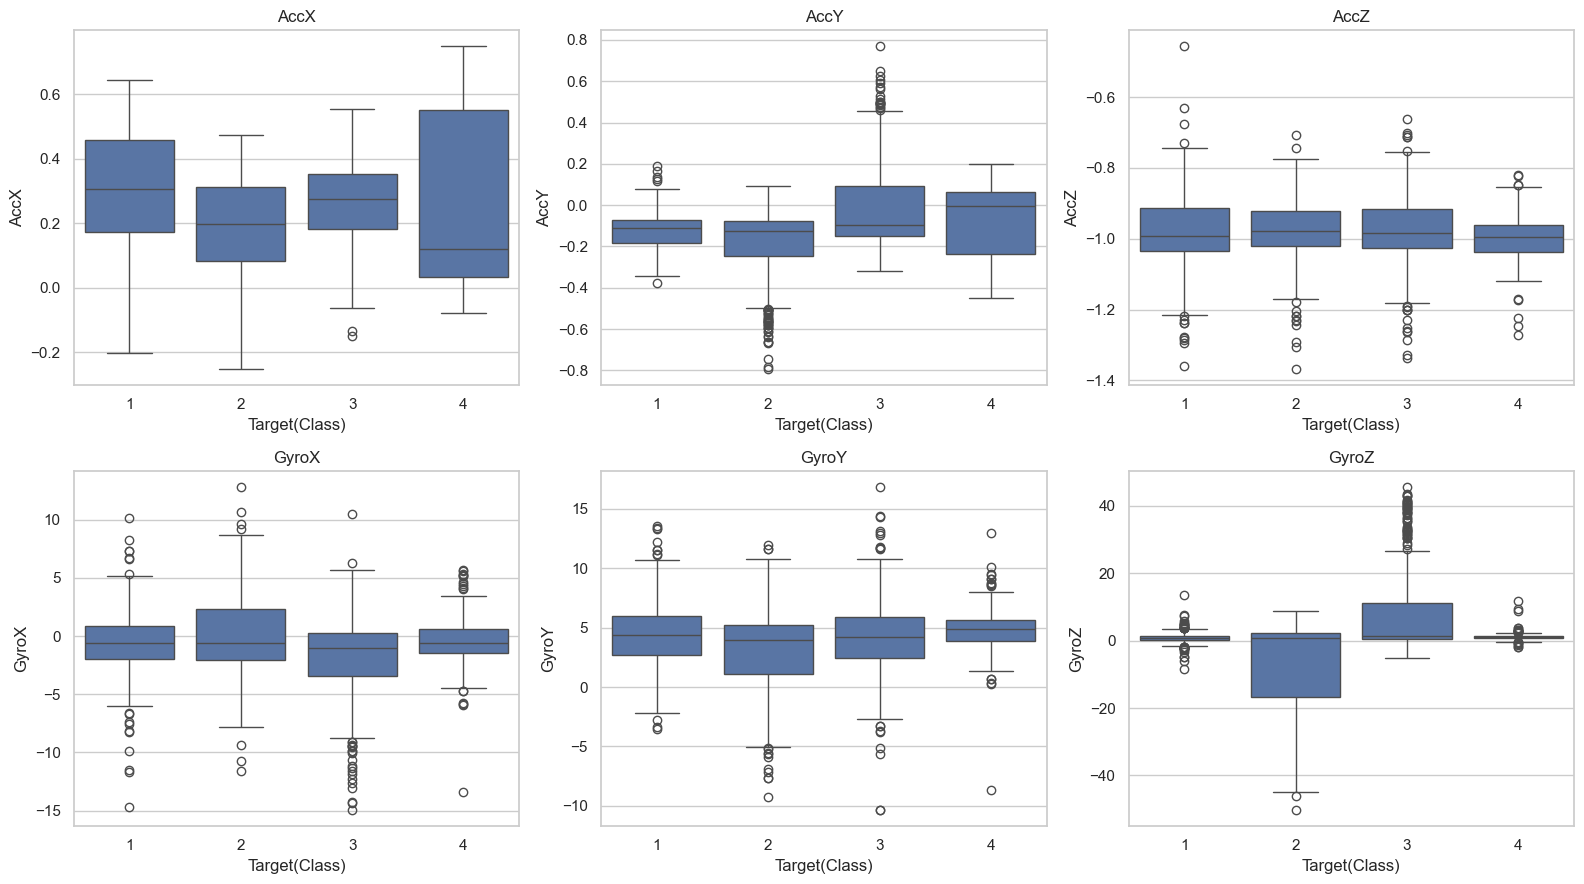

In [24]:
features = ["AccX","AccY","AccZ","GyroX","GyroY","GyroZ"]

fig, axes = plt.subplots(2,3, figsize=(16,9))

for feature, ax in zip(features, axes.flatten()):

    sns.boxplot(
        data=raw_df,
        x="Target(Class)",
        y=feature,
        ax=ax
    )

    ax.set_title(feature)

plt.tight_layout()
plt.savefig("C:/Users/htupk/OneDrive/Desktop/DriveIntel/reports/figures/Boxplots_by_driving_class.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

The boxplots reveal noticeable differences in the distributions of several sensor readings across the four driving behavior classes. Certain gyroscope measurements display larger variability, indicating that rotational motion may be an important distinguishing characteristic.

## Correlation Heatmap

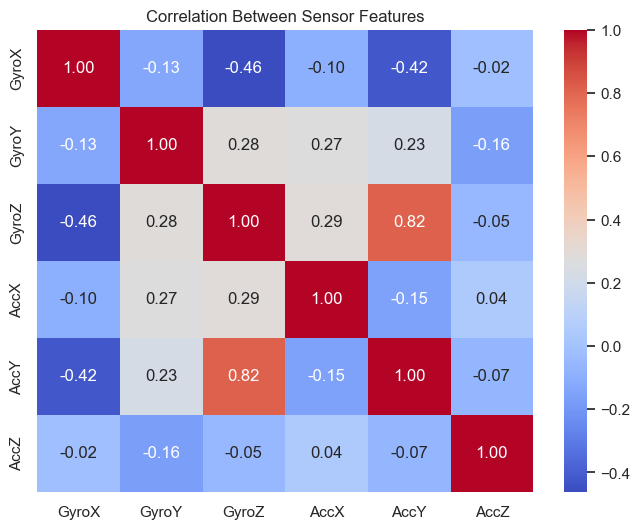

In [25]:
plt.figure(figsize=(8,6))

sns.heatmap(
    raw_df.drop(columns="Target(Class)").corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Between Sensor Features")
plt.savefig("C:/Users/htupk/OneDrive/Desktop/DriveIntel/reports/figures/Correlation_heatmap.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

The correlation matrix illustrates the relationships between sensor variables. Strong correlations indicate that certain motion measurements change together, while weak correlations suggest that they capture different aspects of vehicle movement.

## Pairplot

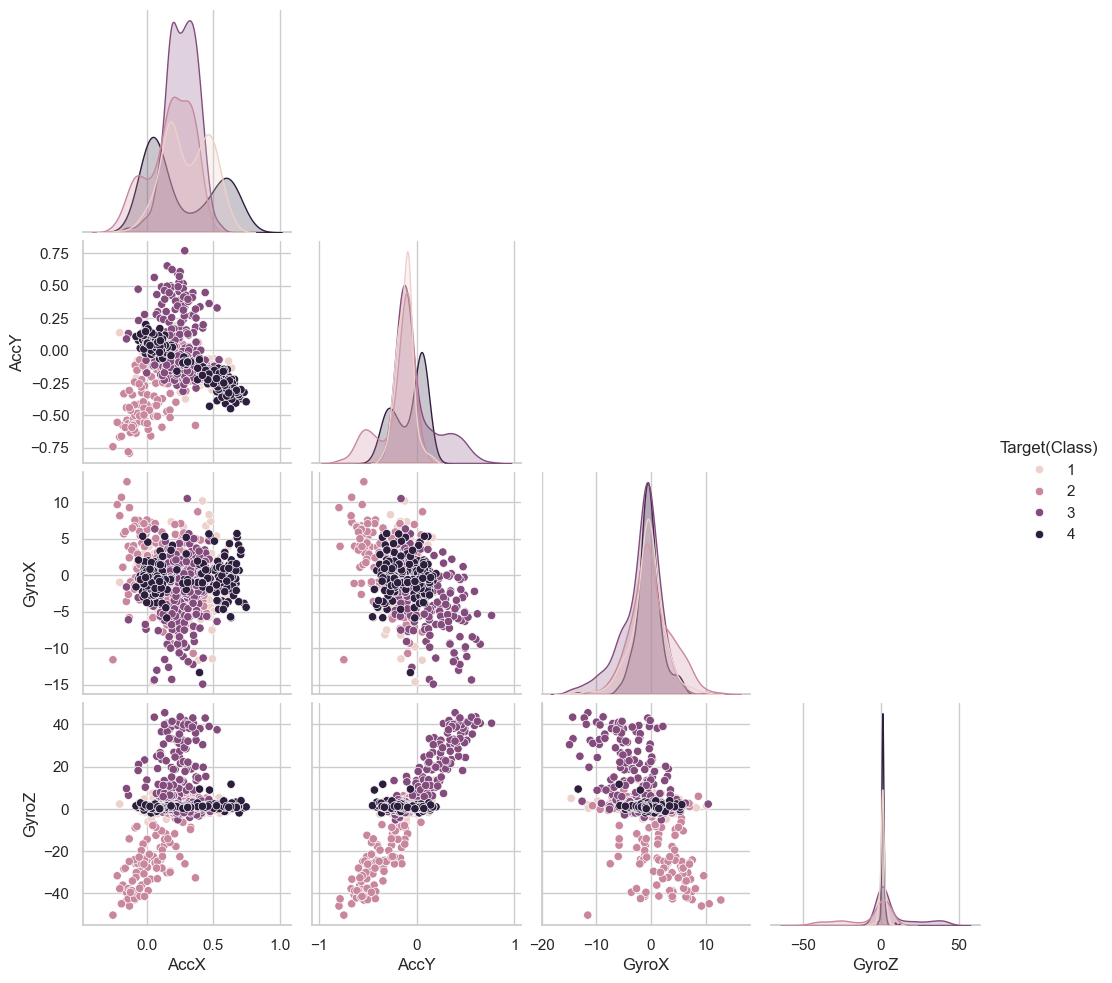

In [26]:
sns.pairplot(
    raw_df,
    vars=["AccX","AccY","GyroX","GyroZ"],
    hue="Target(Class)",
    corner=True
)
plt.savefig("C:/Users/htupk/OneDrive/Desktop/DriveIntel/reports/figures/Pairplot.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

The pairwise plots reveal areas where different driving behavior classes overlap and where they separate. Some combinations of gyroscope and accelerometer measurements appear more effective at distinguishing classes than individual variables alone.

## Mean Sensor Values by Class

In [27]:
mean_values = raw_df.groupby("Target(Class)").mean()

mean_values

,GyroX,GyroY,GyroZ,AccX,AccY,AccZ
Target(Class),,,,,,
1,-0.717345,4.418302,0.858082,0.307267,-0.123029,-0.982635
2,0.006070,3.253896,-7.297922,0.179882,-0.196178,-0.980053
3,-1.829378,4.158408,8.088135,0.265363,-0.004278,-0.976910
4,-0.469943,4.849441,1.133179,0.263741,-0.075681,-0.997782


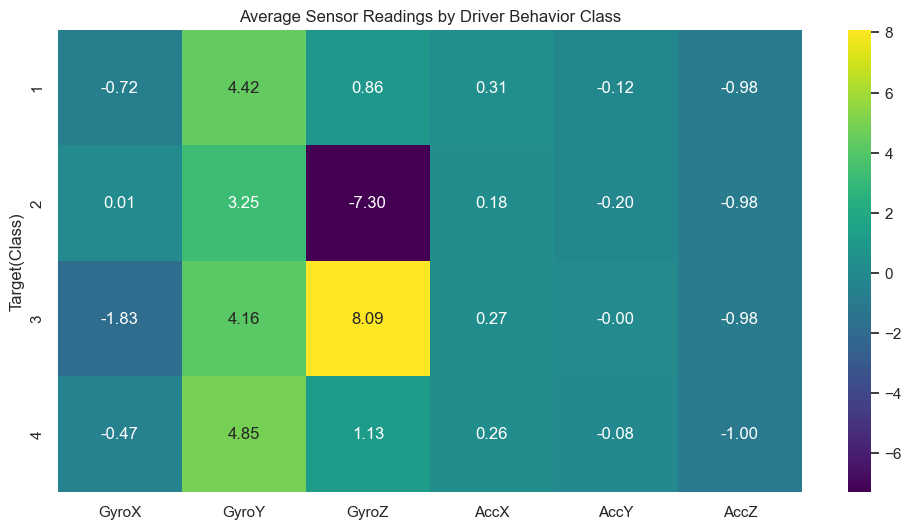

In [28]:
plt.figure(figsize=(12,6))

sns.heatmap(
    mean_values,
    annot=True,
    cmap="viridis",
    fmt=".2f"
)

plt.title("Average Sensor Readings by Driver Behavior Class")
plt.savefig("C:/Users/htupk/OneDrive/Desktop/DriveIntel/reports/figures/Mean_server_value_by_class.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

The average sensor values differ across the four driving behavior classes, indicating that each class exhibits distinct motion characteristics. These differences suggest that the sensor measurements contain useful information for classification.

## Distribution Comparison

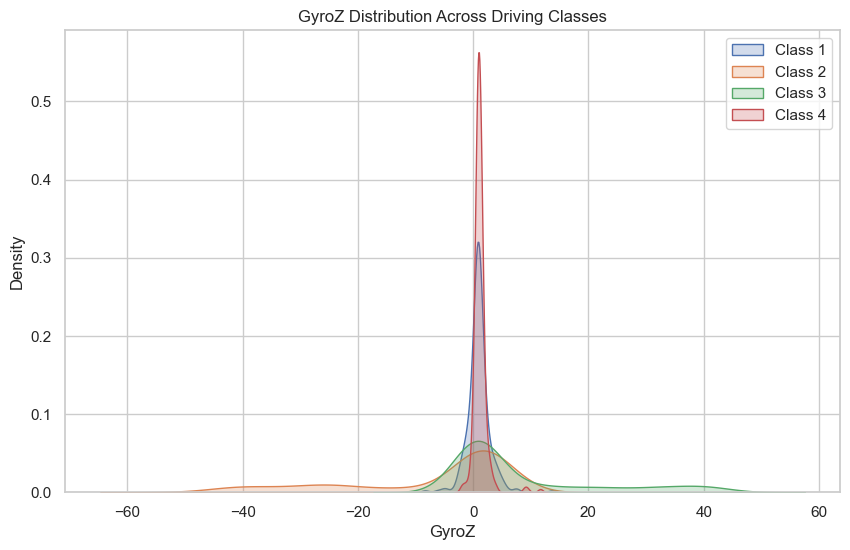

In [29]:
plt.figure(figsize=(10,6))

for driver_class in sorted(raw_df["Target(Class)"].unique()):

    sns.kdeplot(
        data=raw_df[raw_df["Target(Class)"] == driver_class],
        x="GyroZ",
        label=f"Class {driver_class}",
        fill=True,
        alpha=0.25
    )

plt.title("GyroZ Distribution Across Driving Classes")

plt.legend()
plt.savefig("C:/Users/htupk/OneDrive/Desktop/DriveIntel/reports/figures/Distribution_Comparison.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

The GyroZ distributions differ noticeably among the driving behavior classes, suggesting that rotational movement around the vertical axis may be one of the strongest indicators for distinguishing driving styles.

# EDA Summary

The exploratory analysis provides several important insights:

- The datasets are clean with no missing or duplicate values.
- The driving behavior classes are reasonably balanced.
- Sensor variables exhibit different statistical distributions and ranges.
- Boxplots show that several features vary noticeably across classes.
- Correlation analysis identifies relationships among sensor measurements.
- Gyroscope measurements, particularly GyroZ, appear to provide strong separation between driving behaviors.
- These findings motivate the statistical hypothesis testing and machine learning models developed in the following notebooks.